# SETUP

In [1]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40  Python-3.12.10 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Setup complete  (16 CPUs, 15.2 GB RAM, 4.0/10.0 GB disk)


In [2]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA Available: True
Device: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
import os
import shutil

print("Current directory:", os.getcwd())

In [ ]:
%cd E:/Proyek Akhir/Training/datasets

from roboflow import Roboflow

rf = Roboflow(api_key="YPWwyOwSyaIvMkK5gvEi")
project = rf.workspace("winky-ncblh").project("helmet-detection-uurgi")
version = project.version(3)
dataset = version.download("yolov11")

E:\Train_Model_YOLO\datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Helmet-Detection-3 in yolov11:: 100%|██████████| 8240/8240 [00:02<00:00, 3918.02it/s]


In [ ]:
%cd E:/Proyek Akhir/Training

In [ ]:
import yaml

# Path ke data.yaml
yaml_path = "datasets/Helmet-Detection-3/data.yaml"

# Baca nama kelas
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
    class_names = data_yaml["names"]

# Cetak jumlah bbox disertai nama kelas
print("Jumlah bounding box per kelas:")
for class_id, count in class_counts.items():
    class_name = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"
    print(f"{class_name} (ID {class_id}): {count} bbox")

Jumlah bounding box per kelas:
With Chin Strap (ID 0): 799 bbox
Without Chin Strap (ID 2): 361 bbox
With Helmet (ID 1): 4594 bbox
Without Helmet (ID 3): 2562 bbox


# TRAINING

In [ ]:
from ultralytics import YOLO

# Load model
model = YOLO("models/yolo11s.pt")

# Train the model
results = model.train(
    data="datasets/Helmet-Detection-3/data.yaml",
    epochs=110,
    imgsz=416,
    batch=16,
    optimizer="Adam",
    lr0=0.001,
    plots=True,
    project="results/Hasil_Training_YOLOv11_2",
)

New https://pypi.org/project/ultralytics/8.3.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.40  Python-3.12.10 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=yolo11s.pt, data=E:/Train_Model_YOLO/datasets/Helmet-Detection-3/data.yaml, epochs=110, time=None, patience=100, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=E:/Train_Model_YOLO/Hasil_Training_YOLOv11_2, name=train, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=F

train: Scanning E:\Train_Model_YOLO\datasets\Helmet-Detection-3\train\labels... 3783 images, 0 backgrounds, 0 corrupt: 


train: New cache created: E:\Train_Model_YOLO\datasets\Helmet-Detection-3\train\labels.cache


val: Scanning E:\Train_Model_YOLO\datasets\Helmet-Detection-3\valid\labels... 164 images, 0 backgrounds, 0 corrupt: 100

val: New cache created: E:\Train_Model_YOLO\datasets\Helmet-Detection-3\valid\labels.cache


...

    110/110      1.99G     0.6421     0.3566     0.8768         20        416: 100%|██████████| 237/237 [00:36<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<0

                   all        164        355      0.617      0.598      0.638      0.342



110 epochs completed in 1.210 hours.
Optimizer stripped from E:\Train_Model_YOLO\Hasil_Training_YOLOv11_2\train\weights\last.pt, 19.2MB
Optimizer stripped from E:\Train_Model_YOLO\Hasil_Training_YOLOv11_2\train\weights\best.pt, 19.2MB

Validating E:\Train_Model_YOLO\Hasil_Training_YOLOv11_2\train\weights\best.pt...
Ultralytics 8.3.40  Python-3.12.10 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11s summary (fused): 238 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<0


                   all        164        355      0.651      0.598      0.645      0.342
       With Chin Strap         27         31      0.485      0.419      0.389      0.162
           With Helmet        104        179       0.85      0.789      0.892       0.58
    Without Chin Strap         15         18      0.529        0.5      0.549      0.198
        Without Helmet         66        127      0.741      0.685      0.751      0.428
Speed: 0.2ms preprocess, 2.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to E:\Train_Model_YOLO\Hasil_Training_YOLOv11_2\train


In [ ]:
# Load model hasil training
model = YOLO("results/Hasil_Training_YOLOv11_2/train/weights/best.pt")

# Validasi model
results = model.val(
    data="datasets/Helmet-Detection-3/data.yaml",
    save=True,
    project="results/runs2/detect",
    name="val"
)

Ultralytics 8.3.40  Python-3.12.10 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11s summary (fused): 238 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning E:\Train_Model_YOLO\datasets\Helmet-Detection-3\valid\labels.cache... 164 images, 0 backgrounds, 0 corrup
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:02


                   all        164        355       0.65      0.598      0.645      0.341
       With Chin Strap         27         31      0.483      0.419      0.389      0.161
           With Helmet        104        179       0.85      0.789      0.892      0.582
    Without Chin Strap         15         18      0.524        0.5       0.55      0.194
        Without Helmet         66        127      0.742      0.685      0.751      0.428
Speed: 0.6ms preprocess, 5.8ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to E:\Train_Model_YOLO\runs2\detect\val


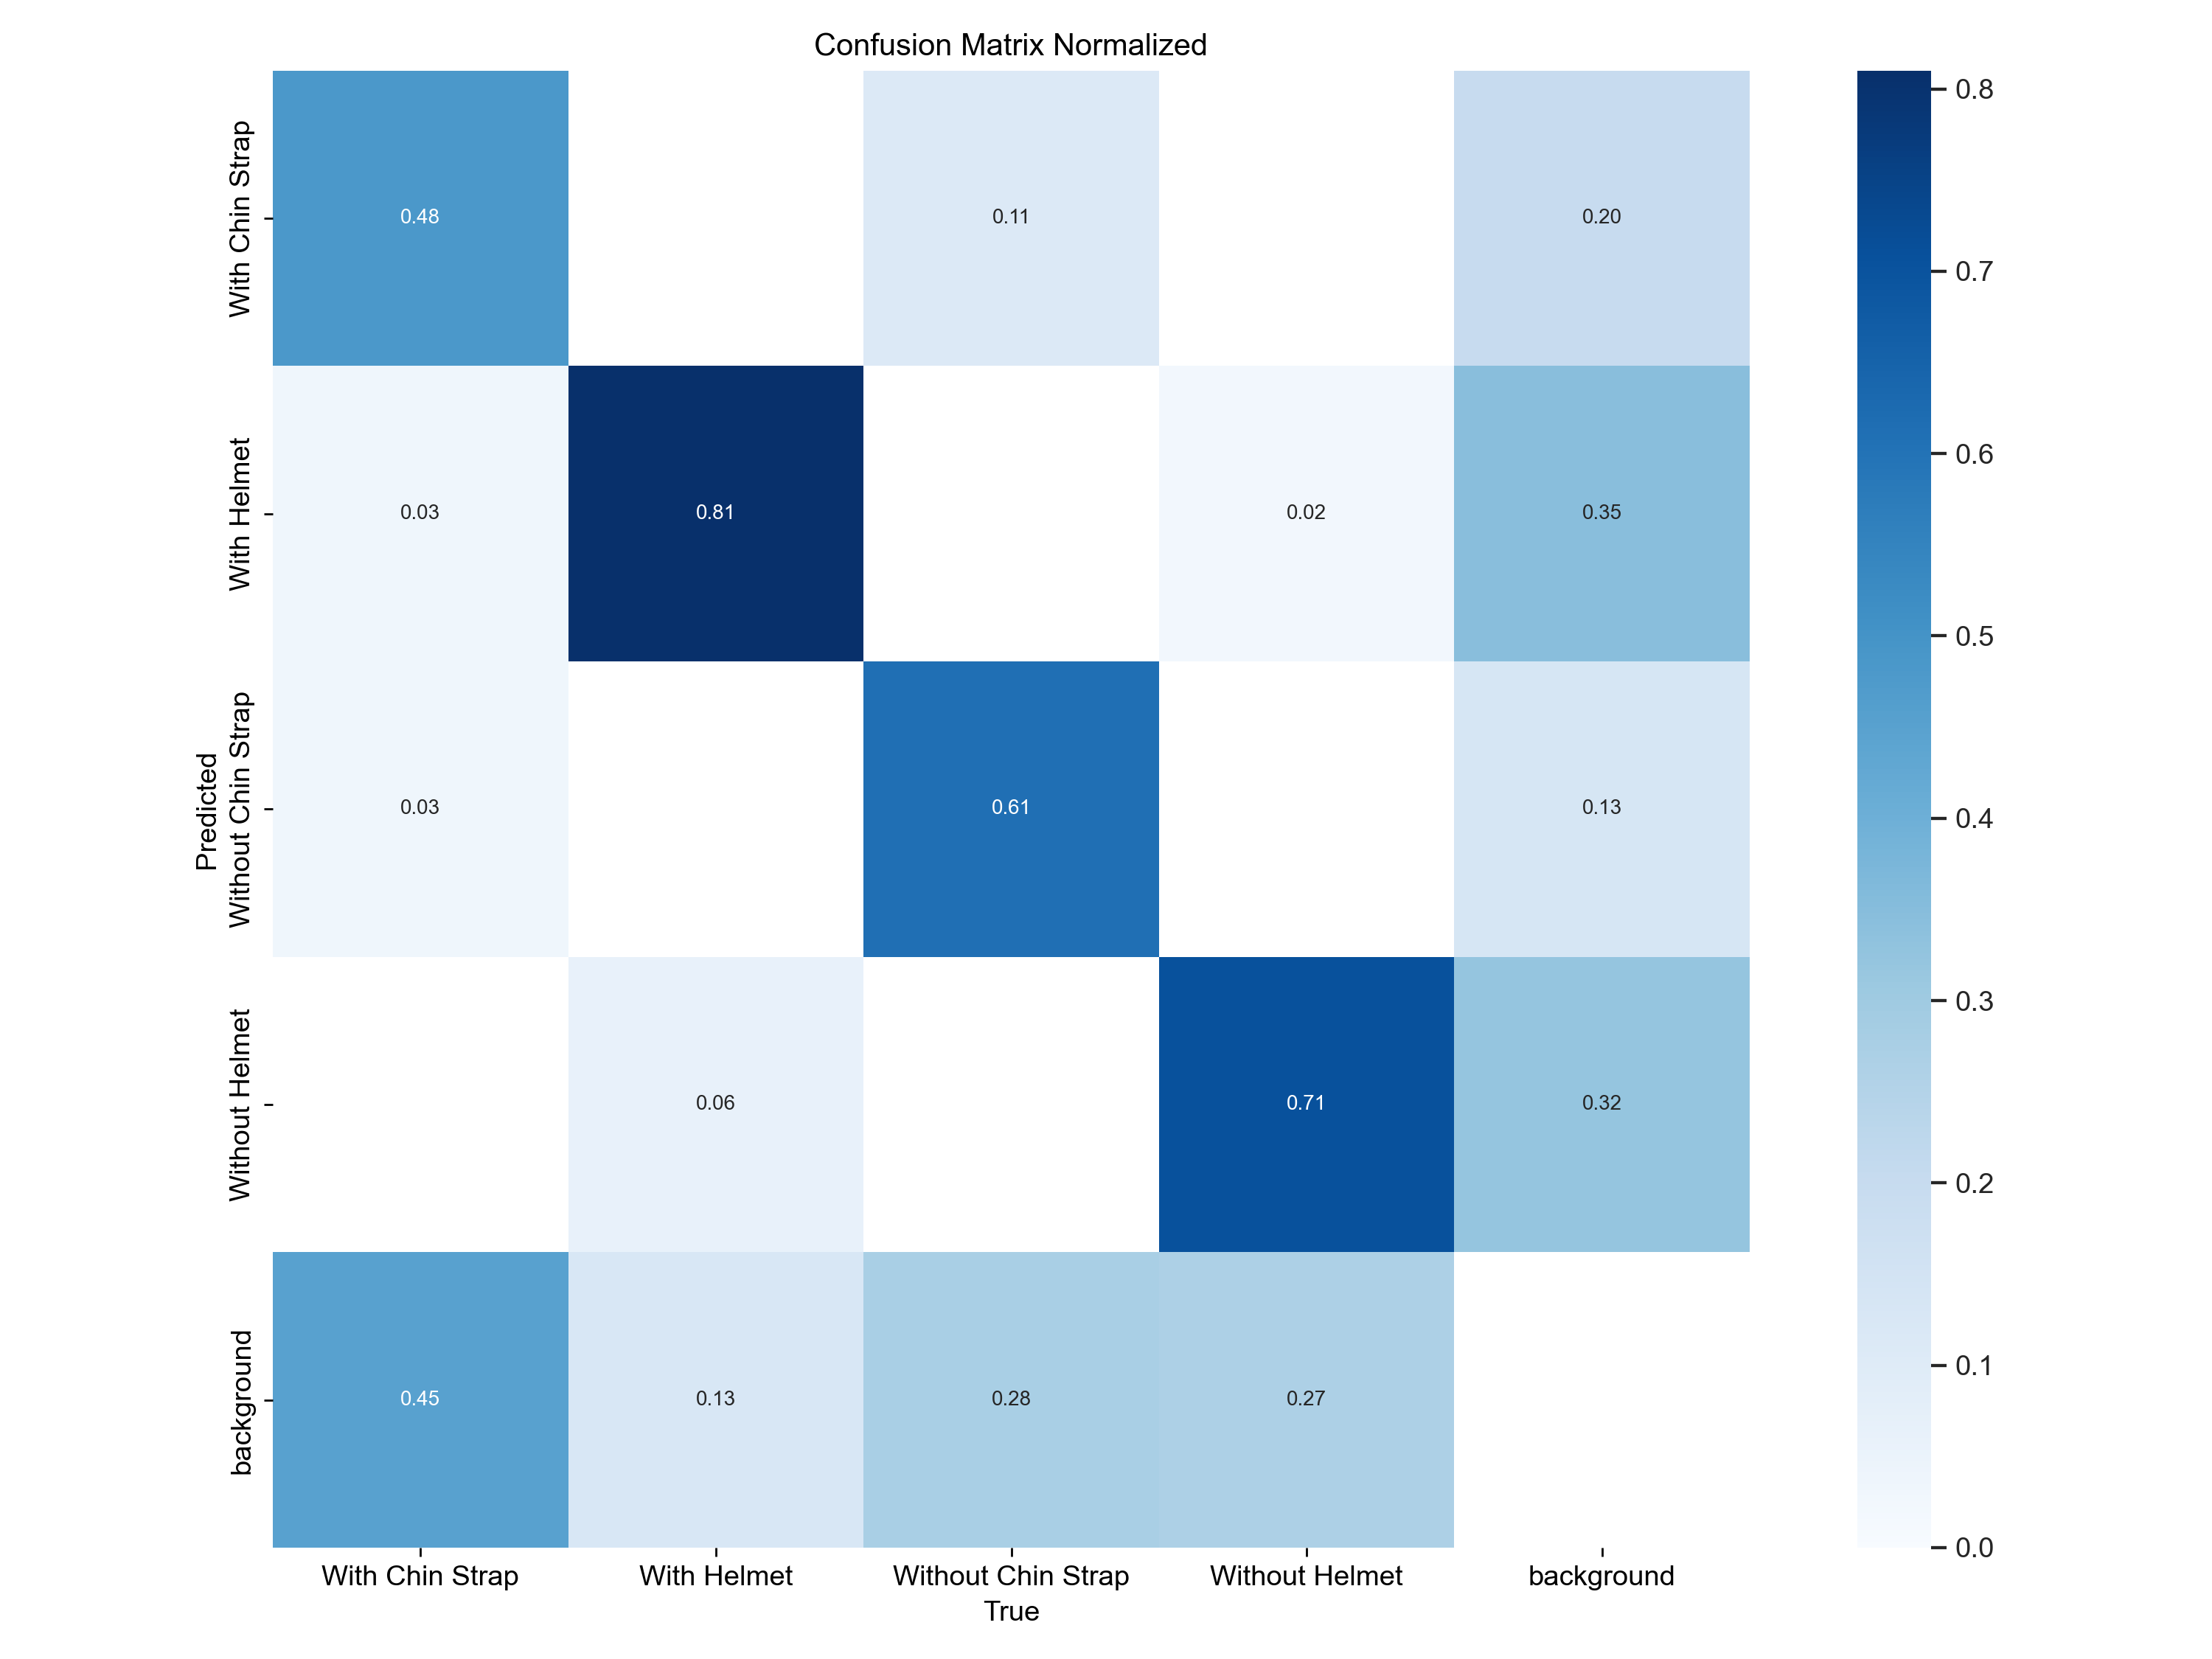

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(filename="results/runs2/detect/val/confusion_matrix_normalized.png", width=600)

In [ ]:
import time
import cv2

model = YOLO("results/Hasil_Training_YOLOv11_2/train/weights/best.pt")

image_path = "datasets/Helmet-Detection-3/test/images/BikesHelmets700_png.rf.06b018c69c93772a794d28d4e8d4a7a9.jpg"
img = cv2.imread(image_path)

start = time.time()
results = model.predict(img)
end = time.time()

print(f"Inference time: {(end - start) * 1000:.2f} ms")


0: 416x416 1 Without Helmet, 11.0ms
Speed: 1.0ms preprocess, 11.0ms inference, 4.3ms postprocess per image at shape (1, 3, 416, 416)
Inference time: 169.50 ms


In [3]:
from ultralytics import YOLO

model = YOLO("Hasil_Training_YOLOv11_2/train/weights/best.pt")
model.export(format="onnx", dynamic=False, opset=12)

Ultralytics 8.3.40  Python-3.12.10 torch-2.6.0+cu118 CPU (AMD Ryzen 7 7735HS with Radeon Graphics)
YOLO11s summary (fused): 238 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'Hasil_Training_YOLOv11_2\train\weights\best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 8, 3549) (18.3 MB)

ONNX: starting export with onnx 1.17.0 opset 12...
ONNX: slimming with onnxslim 0.1.50...
ONNX: export success  2.0s, saved as 'Hasil_Training_YOLOv11_2\train\weights\best.onnx' (36.1 MB)

Export complete (2.5s)
Results saved to E:\Train_Model_YOLO\Hasil_Training_YOLOv11_2\train\weights
Predict:         yolo predict task=detect model=Hasil_Training_YOLOv11_2\train\weights\best.onnx imgsz=416  
Validate:        yolo val task=detect model=Hasil_Training_YOLOv11_2\train\weights\best.onnx imgsz=416 data=E:/Train_Model_YOLO/datasets/Helmet-Detection-3/data.yaml  
Visualize:       https://netron.app


'Hasil_Training_YOLOv11_2\\train\\weights\\best.onnx'

In [4]:
pip install onnx tensorflow onnx-tf

INFO: pip is looking at multiple versions of onnx-tf to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install tensorflow-addons

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow-addons


In [5]:
import onnx
from onnx_tf.backend import prepare
import tensorflow as tf
import os

# Load ONNX model
onnx_model = onnx.load("Hasil_Training_YOLOv11_2/train/weights/best.onnx")

# Konversi ONNX ke TensorFlow SavedModel
tf_rep = prepare(onnx_model)
tf_rep.export_graph("saved_model")

# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

# Simpan model TFLite
with open("best.tflite", "wb") as f:
    f.write(tflite_model)

print("Berhasil dikonversi ke TFLite.")

ModuleNotFoundError: No module named 'tensorflow_addons'